AI-BASED NATURAL DISASTER RISK PREDICTION AND EARLY WARNING SYSTEM                                                                                       
Starting off with FLOOD.                                                                                                                                 
First Stage: DATA CLEANING AND PREPROCESSING


In [1]:
#Step1: Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print('All the libraries imported successfully!')

All the libraries imported successfully!


In [2]:
#Step2: Setting File Paths

NASA_FOLDER = r"C:\Nepal_Flood_Project\Data\Nasa_Data"


EMDAT_FILE = r"C:\Nepal_Flood_Project\Data\em-datdatasetforfloodnepal2000-2025.xlsx"


BIPAD_FILE = r"C:\Nepal_Flood_Project\Data\bipad_flood_nepal_2011-2026.csv"


DHM_FOLDER = r"C:\Nepal_Flood_Project\Data\DHM Data"


OUTPUT_FILE = r'C:\Nepal_Flood_Project\Data\final_flood_dataset.csv'


CITIES = {
    'kathmandu':  {'file': 'ktmnasa.csv',    'lat': 27.72, 'lon': 85.32},
    'pokhara':    {'file': 'pokhara.csv',     'lat': 28.21, 'lon': 83.99},
    'illam':      {'file': 'illam.csv',       'lat': 26.91, 'lon': 87.93},
    'manang':     {'file': 'manangnasa.csv',  'lat': 28.67, 'lon': 84.02},
    'biratnagar': {'file': 'biratnagar.csv',  'lat': 26.45, 'lon': 87.27},
    'nepalgunj':  {'file': 'nepalgunj.csv',   'lat': 28.05, 'lon': 81.62},
    'janakpur':   {'file': 'janakpur.csv',    'lat': 26.73, 'lon': 85.92},
}

print(' File paths set!')
print(f'NASA folder: {NASA_FOLDER}')
print(f'BIPAD file: {BIPAD_FILE}')
print(f'DHM folder: {DHM_FOLDER}')


 File paths set!
NASA folder: C:\Nepal_Flood_Project\Data\Nasa_Data
BIPAD file: C:\Nepal_Flood_Project\Data\bipad_flood_nepal_2011-2026.csv
DHM folder: C:\Nepal_Flood_Project\Data\DHM Data


In [3]:
#Step3: Read Data
def read_nasa_file(filepath, city_name):
    
    
    skip_rows = 0
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if '-END HEADER-' in line:
                skip_rows = i + 1  
                break
    
   
    df = pd.read_csv(filepath, skiprows=skip_rows)
    
   
    df.columns = df.columns.str.strip()
    
   
    df['location'] = city_name
    
    return df



all_cities_data = []  

for city_name, city_info in CITIES.items():
    filepath = os.path.join(NASA_FOLDER, city_info['file'])
    
    
    if os.path.exists(filepath):
        df_city = read_nasa_file(filepath, city_name)
        all_cities_data.append(df_city)
        print(f' Read {city_name}: {len(df_city)} rows')
    else:
        print(f' File not found: {filepath} — check your file name!')


df = pd.concat(all_cities_data, ignore_index=True)

print(f'\n All cities combined!')
print(f'Total rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')

 Read kathmandu: 9497 rows
 Read pokhara: 9497 rows
 Read illam: 9497 rows
 Read manang: 9497 rows
 Read biratnagar: 9497 rows
 Read nepalgunj: 9497 rows
 Read janakpur: 9497 rows

 All cities combined!
Total rows: 66479
Columns: ['YEAR', 'DOY', 'T2M', 'PRECTOTCORR', 'RH2M', 'WS2M', 'location']


In [4]:
#Step4: Convert YEAR + DOY into a proper date column
df['date'] = pd.to_datetime(
    df['YEAR'].astype(str) + '-' + df['DOY'].astype(str),
    format='%Y-%j' 
)


df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year
df['day']   = df['date'].dt.day


def get_season(month):
    if month in [3, 4, 5]:
        return 'pre_monsoon'
    elif month in [6, 7, 8, 9]:
        return 'monsoon'
    elif month in [10, 11]:
        return 'post_monsoon'
    else:
        return 'winter'

df['season'] = df['month'].apply(get_season)


df = df.rename(columns={
    'T2M':          'temperature',
    'PRECTOTCORR':  'rainfall',
    'RH2M':         'humidity',
    'WS2M':         'wind_speed'
})


df = df.drop(columns=['YEAR', 'DOY'], errors='ignore')


df = df.sort_values(['location', 'date']).reset_index(drop=True)

print(' Date conversion done!')
print(df[['date', 'month', 'season', 'location', 'temperature', 'rainfall', 'humidity', 'wind_speed']].head(10))


 Date conversion done!
        date  month  season    location  temperature  rainfall  humidity  \
0 2000-01-01      1  winter  biratnagar        17.16       0.0     32.01   
1 2000-01-02      1  winter  biratnagar        16.94       0.0     33.37   
2 2000-01-03      1  winter  biratnagar        16.42       0.0     32.56   
3 2000-01-04      1  winter  biratnagar        16.00       0.0     31.66   
4 2000-01-05      1  winter  biratnagar        15.98       0.0     31.76   
5 2000-01-06      1  winter  biratnagar        15.61       0.0     33.61   
6 2000-01-07      1  winter  biratnagar        15.41       0.0     30.33   
7 2000-01-08      1  winter  biratnagar        14.65       0.0     31.70   
8 2000-01-09      1  winter  biratnagar        14.87       0.0     31.99   
9 2000-01-10      1  winter  biratnagar        15.36       0.0     35.09   

   wind_speed  
0        0.98  
1        1.20  
2        1.17  
3        1.07  
4        1.21  
5        1.29  
6        1.41  
7        1.0

In [5]:
df = df.replace(-999, np.nan)
print('Missing-value markers cleaned.')

Missing-value markers cleaned.


In [6]:
# Step 5: Loading DHM discharge data + build station lookup
import re

TERAI_CITIES    = ['biratnagar', 'janakpur', 'nepalgunj']
HILLY_CITIES    = ['kathmandu', 'pokhara', 'illam']
MOUNTAIN_CITIES = ['manang']

STATION_CITY = {
    '550.05': 'kathmandu',
    '695':    'biratnagar',
    '280':    'nepalgunj',
    '430.5':  'pokhara',
    '795':    'illam',
    '439.7':  'manang',
}


CITY_DISTRICT = {
    'kathmandu':  'Kathmandu',
    'pokhara':    'Kaski',
    'illam':      'Ilam',
    'manang':     'Manang',
    'biratnagar': 'Morang',
    'nepalgunj':  'Banke',
    'janakpur':   'Dhanusa',
}

def read_dhm_file(filepath):
    records = []
    with open(filepath, 'r', errors='ignore') as f:
        for line in f:
            line = line.strip()
            m = re.match(r'(\d{2}/\w+/\d{4}),(\S+)', line)
            if m:
                try:
                    date = pd.to_datetime(m.group(1), format='%d/%b/%Y').date()
                    discharge = float(m.group(2))
                    records.append({'date': date, 'discharge': discharge})
                except:
                    pass
    return pd.DataFrame(records)

discharge_lookup = {}
for station_no, city in STATION_CITY.items():
    filepath = os.path.join(DHM_FOLDER, f'DFL_{station_no}.txt')
    if os.path.exists(filepath):
        df_st = read_dhm_file(filepath)
        discharge_lookup[city] = df_st.set_index('date')['discharge'].to_dict()
        print(f'DHM loaded {city}: {len(df_st)} records')

FLOOD_THRESHOLDS = {}
for city, d in discharge_lookup.items():
    pre2011_vals = [v for dt, v in d.items() if dt.year <= 2010]
    FLOOD_THRESHOLDS[city] = {
        'medium': np.percentile(pre2011_vals, 95),
        'high':   np.percentile(pre2011_vals, 99)
    }
    print(f'{city:12} → Medium: >{FLOOD_THRESHOLDS[city]["medium"]:.1f} | High: >{FLOOD_THRESHOLDS[city]["high"]:.1f} m³/s')

FLOOD_THRESHOLDS['janakpur'] = {
    'medium': (FLOOD_THRESHOLDS['biratnagar']['medium'] + FLOOD_THRESHOLDS['nepalgunj']['medium']) / 2,
    'high':   (FLOOD_THRESHOLDS['biratnagar']['high']   + FLOOD_THRESHOLDS['nepalgunj']['high'])   / 2
}
print(f'janakpur     → Medium: >{FLOOD_THRESHOLDS["janakpur"]["medium"]:.1f} | High: >{FLOOD_THRESHOLDS["janakpur"]["high"]:.1f} m³/s (estimated)')

DHM loaded kathmandu: 8605 records
DHM loaded biratnagar: 8525 records
DHM loaded nepalgunj: 8766 records
DHM loaded pokhara: 7305 records
DHM loaded illam: 5823 records
DHM loaded manang: 7011 records
kathmandu    → Medium: >56.9 | High: >115.8 m³/s
biratnagar   → Medium: >5271.3 | High: >6897.1 m³/s
nepalgunj    → Medium: >4823.7 | High: >6454.0 m³/s
pokhara      → Medium: >355.0 | High: >600.6 m³/s
illam        → Medium: >261.4 | High: >792.3 m³/s
manang       → Medium: >736.8 | High: >1007.8 m³/s
janakpur     → Medium: >5047.5 | High: >6675.5 m³/s (estimated)


In [7]:
# Step 6: Adding discharge as a feature
def get_discharge(row):
    city = row['location'].lower()
    row_date = pd.Timestamp(row['date']).date()
    if city in discharge_lookup:
        city_vals = discharge_lookup[city]
        return city_vals.get(row_date, np.mean(list(city_vals.values())))
    elif city == 'janakpur':
        d1 = discharge_lookup.get('biratnagar', {}).get(row_date)
        d2 = discharge_lookup.get('nepalgunj', {}).get(row_date)
        if d1 is not None and d2 is not None:
            return (d1 + d2) / 2
        m1 = np.mean(list(discharge_lookup.get('biratnagar', {0: 0}).values()))
        m2 = np.mean(list(discharge_lookup.get('nepalgunj', {0: 0}).values()))
        return (m1 + m2) / 2
    return 0

df['discharge'] = df.apply(get_discharge, axis=1)
print('Discharge feature added!')
print('\nAverage discharge by city:')
print(df.groupby('location')['discharge'].mean().round(1))

Discharge feature added!

Average discharge by city:
location
biratnagar    1679.3
illam           74.4
janakpur      1520.8
kathmandu       15.5
manang         226.1
nepalgunj     1347.2
pokhara         99.0
Name: discharge, dtype: float64


In [8]:
# Step 7: Loading BIPAD data 
bipad = pd.read_csv(BIPAD_FILE, low_memory=False)
bipad = bipad[bipad['Hazard'] == 'Flood'].copy()
bipad['incident_date'] = pd.to_datetime(bipad['Incident on']).dt.date

print(f'BIPAD loaded: {len(bipad)} flood incidents')
print(f'Date range: {bipad["incident_date"].min()} to {bipad["incident_date"].max()}')

bipad_high_dates = {}
bipad_medium_dates = {}

for city, district in CITY_DISTRICT.items():
    city_dates = set(bipad.loc[bipad['District'] == district, 'incident_date'])
    bipad_high_dates[city] = city_dates

    med = set()
    for d in city_dates:
        for days_before in range(1, 8):
            pre = d - pd.Timedelta(days=days_before)
            pre = pre.date() if hasattr(pre, 'date') else pre
            if pre not in city_dates:
                med.add(pre)
    bipad_medium_dates[city] = med

    print(f'{city:12} ({district:10}) → High days: {len(city_dates):4} | Medium spillover days: {len(med)}')

BIPAD loaded: 2874 flood incidents
Date range: 2011-06-05 to 2026-07-14
kathmandu    (Kathmandu ) → High days:   63 | Medium spillover days: 367
pokhara      (Kaski     ) → High days:   57 | Medium spillover days: 322
illam        (Ilam      ) → High days:   37 | Medium spillover days: 166
manang       (Manang    ) → High days:    9 | Medium spillover days: 49
biratnagar   (Morang    ) → High days:   60 | Medium spillover days: 236
nepalgunj    (Banke     ) → High days:   34 | Medium spillover days: 182
janakpur     (Dhanusa   ) → High days:   16 | Medium spillover days: 73


In [9]:
# Step 8: Assigning flood risk labels 
def assign_flood_risk(row):
    row_date = pd.Timestamp(row['date']).date()
    city = row['location'].lower()
    year = row['date'].year

    if city in MOUNTAIN_CITIES:
        return 'Low'

    if year <= 2010:
        discharge = None
        if city in discharge_lookup:
            discharge = discharge_lookup[city].get(row_date, None)
        elif city == 'janakpur':
            d1 = discharge_lookup.get('biratnagar', {}).get(row_date, None)
            d2 = discharge_lookup.get('nepalgunj', {}).get(row_date, None)
            if d1 is not None and d2 is not None:
                discharge = (d1 + d2) / 2

        if discharge is not None and city in FLOOD_THRESHOLDS:
            thresh = FLOOD_THRESHOLDS[city]
            if discharge >= thresh['high']:
                return 'High' if city in TERAI_CITIES else 'Medium'
            elif discharge >= thresh['medium']:
                return 'Medium'
        return 'Low'

    if row_date in bipad_high_dates.get(city, set()):
        return 'High' if city in TERAI_CITIES else 'Medium'
    if row_date in bipad_medium_dates.get(city, set()):
        return 'Medium'
    return 'Low'

df['flood_risk'] = df.apply(assign_flood_risk, axis=1)
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['flood_risk_label'] = df['flood_risk'].map(risk_mapping)

print('Flood risk labels assigned!')
print('\nLabel distribution:')
print(df['flood_risk'].value_counts())
print('\nLabel % distribution:')
print(df['flood_risk'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print('\nLabel by city:')
print(df.groupby('location')['flood_risk'].value_counts().unstack(fill_value=0))

Flood risk labels assigned!

Label distribution:
flood_risk
Low       63806
Medium     2463
High        210
Name: count, dtype: int64

Label % distribution:
flood_risk
Low       96.0%
Medium     3.7%
High       0.3%
Name: proportion, dtype: object

Label by city:
flood_risk  High   Low  Medium
location                      
biratnagar   101  9000     396
illam          0  9163     334
janakpur      35  9237     225
kathmandu      0  8889     608
manang         0  9497       0
nepalgunj     74  9088     335
pokhara        0  8932     565


In [10]:
# Step 9: Rolling window features 
df = df.sort_values(['location', 'date']).reset_index(drop=True)

for window in [3, 7]:
    df[f'rainfall_roll{window}'] = (
        df.groupby('location')['rainfall']
          .transform(lambda x: x.rolling(window, min_periods=1).sum())
    )
    df[f'discharge_roll{window}'] = (
        df.groupby('location')['discharge']
          .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

print('Rolling features added:', [c for c in df.columns if 'roll' in c])
print(df[['location', 'date', 'rainfall', 'rainfall_roll3', 'rainfall_roll7',
          'discharge', 'discharge_roll3', 'discharge_roll7']].head(10))

Rolling features added: ['rainfall_roll3', 'discharge_roll3', 'rainfall_roll7', 'discharge_roll7']
     location       date  rainfall  rainfall_roll3  rainfall_roll7  discharge  \
0  biratnagar 2000-01-01       0.0             0.0             0.0      479.0   
1  biratnagar 2000-01-02       0.0             0.0             0.0      473.0   
2  biratnagar 2000-01-03       0.0             0.0             0.0      469.0   
3  biratnagar 2000-01-04       0.0             0.0             0.0      460.0   
4  biratnagar 2000-01-05       0.0             0.0             0.0      451.0   
5  biratnagar 2000-01-06       0.0             0.0             0.0      439.0   
6  biratnagar 2000-01-07       0.0             0.0             0.0      438.0   
7  biratnagar 2000-01-08       0.0             0.0             0.0      427.0   
8  biratnagar 2000-01-09       0.0             0.0             0.0      428.0   
9  biratnagar 2000-01-10       0.0             0.0             0.0      424.0   

   discha

In [13]:
#Step10: Validating Labels Against EM-DAT
emdat = pd.read_excel(EMDAT_FILE, sheet_name='EM-DAT Data')
print(f' EM-DAT loaded: {len(emdat)} flood records')
print(emdat[['DisNo.', 'Start Year', 'Start Month', 'Start Day',
             'End Year', 'End Month', 'End Day', 'Location', 'Total Deaths']].head(10))

def make_date(year, month, day):
    try:
        y = int(year) if not pd.isna(year) else None
        m = int(month) if not pd.isna(month) else 1
        d = int(day) if not pd.isna(day) else 1
        if y:
            return pd.Timestamp(year=y, month=m, day=d)
    except:
        return None
    return None

emdat['event_start'] = emdat.apply(
    lambda r: make_date(r['Start Year'], r['Start Month'], r['Start Day']), axis=1)
emdat['event_end'] = emdat.apply(
    lambda r: make_date(r['End Year'], r['End Month'], r['End Day']), axis=1)
emdat['event_end'] = emdat.apply(
    lambda r: r['event_start'] + pd.Timedelta(days=7)
    if pd.isna(r['event_end']) else r['event_end'], axis=1
)

print('\n Checking our labels against EM-DAT flood events:\n')
print(f'{"Event ID":<20} {"Start":<15} {"End":<15} {"High%":<10} {"Med%":<10} {"Low%":<10} {"Result"}')
print('-' * 90)
match_count = 0
total_events = 0
for _, event in emdat.iterrows():
    if pd.isna(event['event_start']):
        continue

    mask = (df['date'] >= event['event_start']) & (df['date'] <= event['event_end'])
    event_rows = df[mask]

    if len(event_rows) == 0:
        continue

    total_events += 1
    label_counts = event_rows['flood_risk'].value_counts(normalize=True).mul(100).round(1)

    high_pct = label_counts.get('High', 0)
    med_pct  = label_counts.get('Medium', 0)
    low_pct  = label_counts.get('Low', 0)

    result = 'Good match' if (high_pct + med_pct) >= 30 else 'Check threshold'
    if result == 'Good match':
        match_count += 1

    dis_id = str(event['DisNo.'])[:18]
    print(f'{dis_id:<20} {str(event["event_start"].date()):<15} {str(event["event_end"].date()):<15} {high_pct:<10} {med_pct:<10} {low_pct:<10} {result}')

print(f'\n Validation complete: {match_count}/{total_events} events matched our High/Medium labels')
if match_count / total_events >= 0.6:
    print(' Labels look good! Thresholds are working well.')
else:
    print(' Consider lowering the High Risk threshold slightly.')

 EM-DAT loaded: 38 flood records
          DisNo.  Start Year  Start Month  Start Day  End Year  End Month  \
0  2017-0342-NPL        2017            8       10.0      2017          9   
1  2022-0590-NPL        2022            9        9.0      2022          9   
2  2016-0275-NPL        2016            6       29.0      2016          7   
3  2024-0428-NPL        2024            6        NaN      2024          7   
4  2014-0246-NPL        2014            7        1.0      2014          7   
5  2023-0326-NPL        2023            6       15.0      2023          6   
6  2024-0692-NPL        2024            9       26.0      2024         10   
7  2004-0298-NPL        2004            7        5.0      2004          7   
8  2005-0556-NPL        2005            9       24.0      2005          9   
9  2006-0342-NPL        2006            6       24.0      2006          8   

   End Day                                           Location  Total Deaths  
0      7.0  Lalitpur, Palpa, Jhapa, Moran

In [15]:
# Step 10b: Improved EM-DAT validation 
def match_cities(location_text):
    if pd.isna(location_text):
        return []
    matched = []
    for city, district in CITY_DISTRICT.items():
        if district.lower() in str(location_text).lower():
            matched.append(city)
    return matched

match_count = 0
total_events = 0
skipped_no_city = 0

for _, event in emdat.iterrows():
    if pd.isna(event['event_start']):
        continue

    matched_cities = match_cities(event['Location'])
    if not matched_cities:
        skipped_no_city += 1
        continue

    mask = (
        (df['date'] >= event['event_start']) &
        (df['date'] <= event['event_end']) &
        (df['location'].isin(matched_cities))
    )
    event_rows = df[mask]
    if len(event_rows) == 0:
        continue

    total_events += 1
    had_signal = (event_rows['flood_risk'] != 'Low').any()
    result = 'Good match' if had_signal else 'No signal'
    if had_signal:
        match_count += 1

    dis_id = str(event['DisNo.'])[:18]
    print(f'{dis_id:<20} cities={",".join(matched_cities):<25} days={len(event_rows):<5} {result}')

print(f'\nValidated: {match_count}/{total_events} events had at least one High/Medium day in an affected city')
print(f'Skipped (no city match in Location text): {skipped_no_city}')

2017-0342-NPL        cities=pokhara,biratnagar,nepalgunj days=87    Good match
2023-0326-NPL        cities=illam                     days=5     Good match
2024-0692-NPL        cities=kathmandu                 days=13    Good match
2004-0298-NPL        cities=biratnagar                days=9     Good match
2006-0342-NPL        cities=pokhara,nepalgunj         days=82    Good match
2009-0434-NPL        cities=nepalgunj                 days=9     Good match
2008-0431-NPL        cities=nepalgunj                 days=8     Good match
2012-0186-NPL        cities=pokhara                   days=3     No signal
2013-0576-NPL        cities=biratnagar                days=53    Good match
2014-0272-NPL        cities=pokhara,nepalgunj         days=30    Good match
2016-0267-NPL        cities=nepalgunj                 days=3     Good match
2018-0219-NPL        cities=kathmandu,nepalgunj       days=22    Good match
2003-0341-NPL        cities=nepalgunj                 days=49    Good match
2005-0375-

In [16]:
# Step 11: Encoding categorical columns
from sklearn.preprocessing import LabelEncoder

le_location = LabelEncoder()
df['location_encoded'] = le_location.fit_transform(df['location'])

le_season = LabelEncoder()
df['season_encoded'] = le_season.fit_transform(df['season'])

risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['flood_risk_label'] = df['flood_risk'].map(risk_mapping)

print('Encoding done!')
print('\nLocation encoding:')
for i, city in enumerate(le_location.classes_):
    print(f'  {city} → {i}')
print('\nSeason encoding:')
for i, season in enumerate(le_season.classes_):
    print(f'  {season} → {i}')
print('\nRisk label encoding:')
for label, code in risk_mapping.items():
    print(f'  {label} → {code}')

Encoding done!

Location encoding:
  biratnagar → 0
  illam → 1
  janakpur → 2
  kathmandu → 3
  manang → 4
  nepalgunj → 5
  pokhara → 6

Season encoding:
  monsoon → 0
  post_monsoon → 1
  pre_monsoon → 2
  winter → 3

Risk label encoding:
  Low → 0
  Medium → 1
  High → 2


In [17]:
# Step 12: Checking for missing values
print('Missing values in each column:')
print(df.isnull().sum())

numeric_cols = ['temperature', 'rainfall', 'humidity', 'wind_speed',
                 'discharge', 'rainfall_roll3', 'rainfall_roll7',
                 'discharge_roll3', 'discharge_roll7']

for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        df[col] = df[col].fillna(df[col].mean())
        print(f'Filled {missing} missing values in {col} with mean')

print('\nMissing values handled!')
print('Remaining missing values:', df.isnull().sum().sum())

Missing values in each column:
temperature         0
rainfall            0
humidity            0
wind_speed          0
location            0
date                0
month               0
year                0
day                 0
season              0
discharge           0
flood_risk          0
flood_risk_label    0
rainfall_roll3      0
discharge_roll3     0
rainfall_roll7      0
discharge_roll7     0
location_encoded    0
season_encoded      0
dtype: int64

Missing values handled!
Remaining missing values: 0


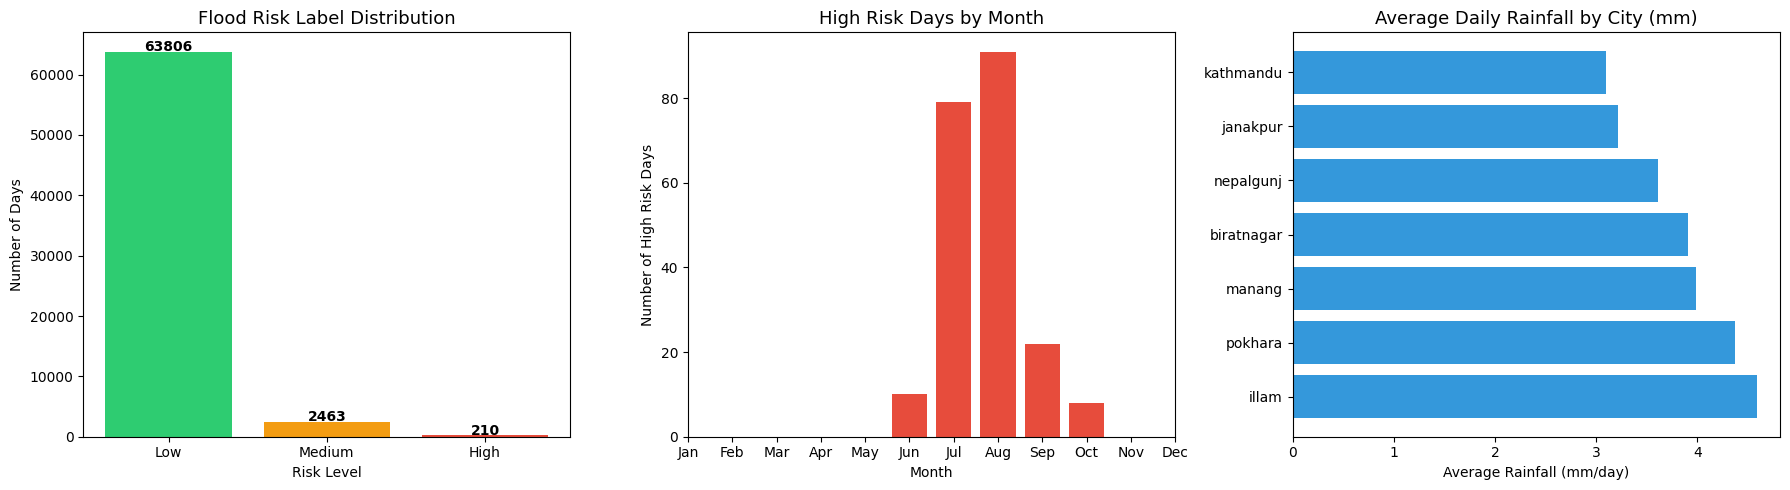

Charts saved!


In [18]:
# Step 13: Exploring the data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Label distribution
label_counts = df['flood_risk'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
axes[0].bar(label_counts.index, label_counts.values,
            color=[colors[['Low', 'Medium', 'High'].index(l)] for l in label_counts.index])
axes[0].set_title('Flood Risk Label Distribution', fontsize=13)
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Days')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Chart 2: High Risk days by month
high_by_month = df[df['flood_risk'] == 'High'].groupby('month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(high_by_month.index, high_by_month.values, color='#e74c3c')
axes[1].set_title('High Risk Days by Month', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of High Risk Days')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)

# Chart 3: Average rainfall by city
avg_rain = df.groupby('location')['rainfall'].mean().sort_values(ascending=False)
axes[2].barh(avg_rain.index, avg_rain.values, color='#3498db')
axes[2].set_title('Average Daily Rainfall by City (mm)', fontsize=13)
axes[2].set_xlabel('Average Rainfall (mm/day)')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved!')

In [20]:
# Step 14: Saving the final dataset
df.to_csv(OUTPUT_FILE, index=False)
print(f'Full dataset saved to: {OUTPUT_FILE}')

ml_features = [
    'temperature',
    'rainfall',
    'humidity',
    'wind_speed',
    'discharge',
    'rainfall_roll3',
    'rainfall_roll7',
    'discharge_roll3',
    'discharge_roll7',
    'month',
    'season_encoded',
    'location_encoded',
    'flood_risk_label'
]

df_ml = df[ml_features]
ml_output = OUTPUT_FILE.replace('.csv', '_ml_ready.csv')
df_ml.to_csv(ml_output, index=False)
print(f'ML-ready dataset saved to: {ml_output}')

print(f'\nFinal dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'ML-ready shape: {df_ml.shape[0]} rows × {df_ml.shape[1]} columns')
print('\nFinal label distribution:')
print(df['flood_risk'].value_counts())
print('\nData pipeline complete! Ready for ML model training.')

Full dataset saved to: C:\Nepal_Flood_Project\Data\final_flood_dataset.csv
ML-ready dataset saved to: C:\Nepal_Flood_Project\Data\final_flood_dataset_ml_ready.csv

Final dataset shape: 66479 rows × 19 columns
ML-ready shape: 66479 rows × 13 columns

Final label distribution:
flood_risk
Low       63806
Medium     2463
High        210
Name: count, dtype: int64

Data pipeline complete! Ready for ML model training.
